### There are two main benefits to using transfer learning:  

1-Can leverage an existing neural network architecture proven to work on problems similar to our own.  
2-Can leverage a working neural network architecture which has already learned patterns on similar data to our own. This often results in achieving great results with less custom data.  

### What we're going to cover
We're going to go through the following with TensorFlow:  

Introduce transfer learning (a way to beat all of our old self-built models)  
Using a smaller dataset to experiment faster (10% of training samples of 10 classes of food)  
Build a transfer learning feature extraction model using TensorFlow Hub  
Introduce the TensorBoard callback to track model training results  
Compare model results using TensorBoard  
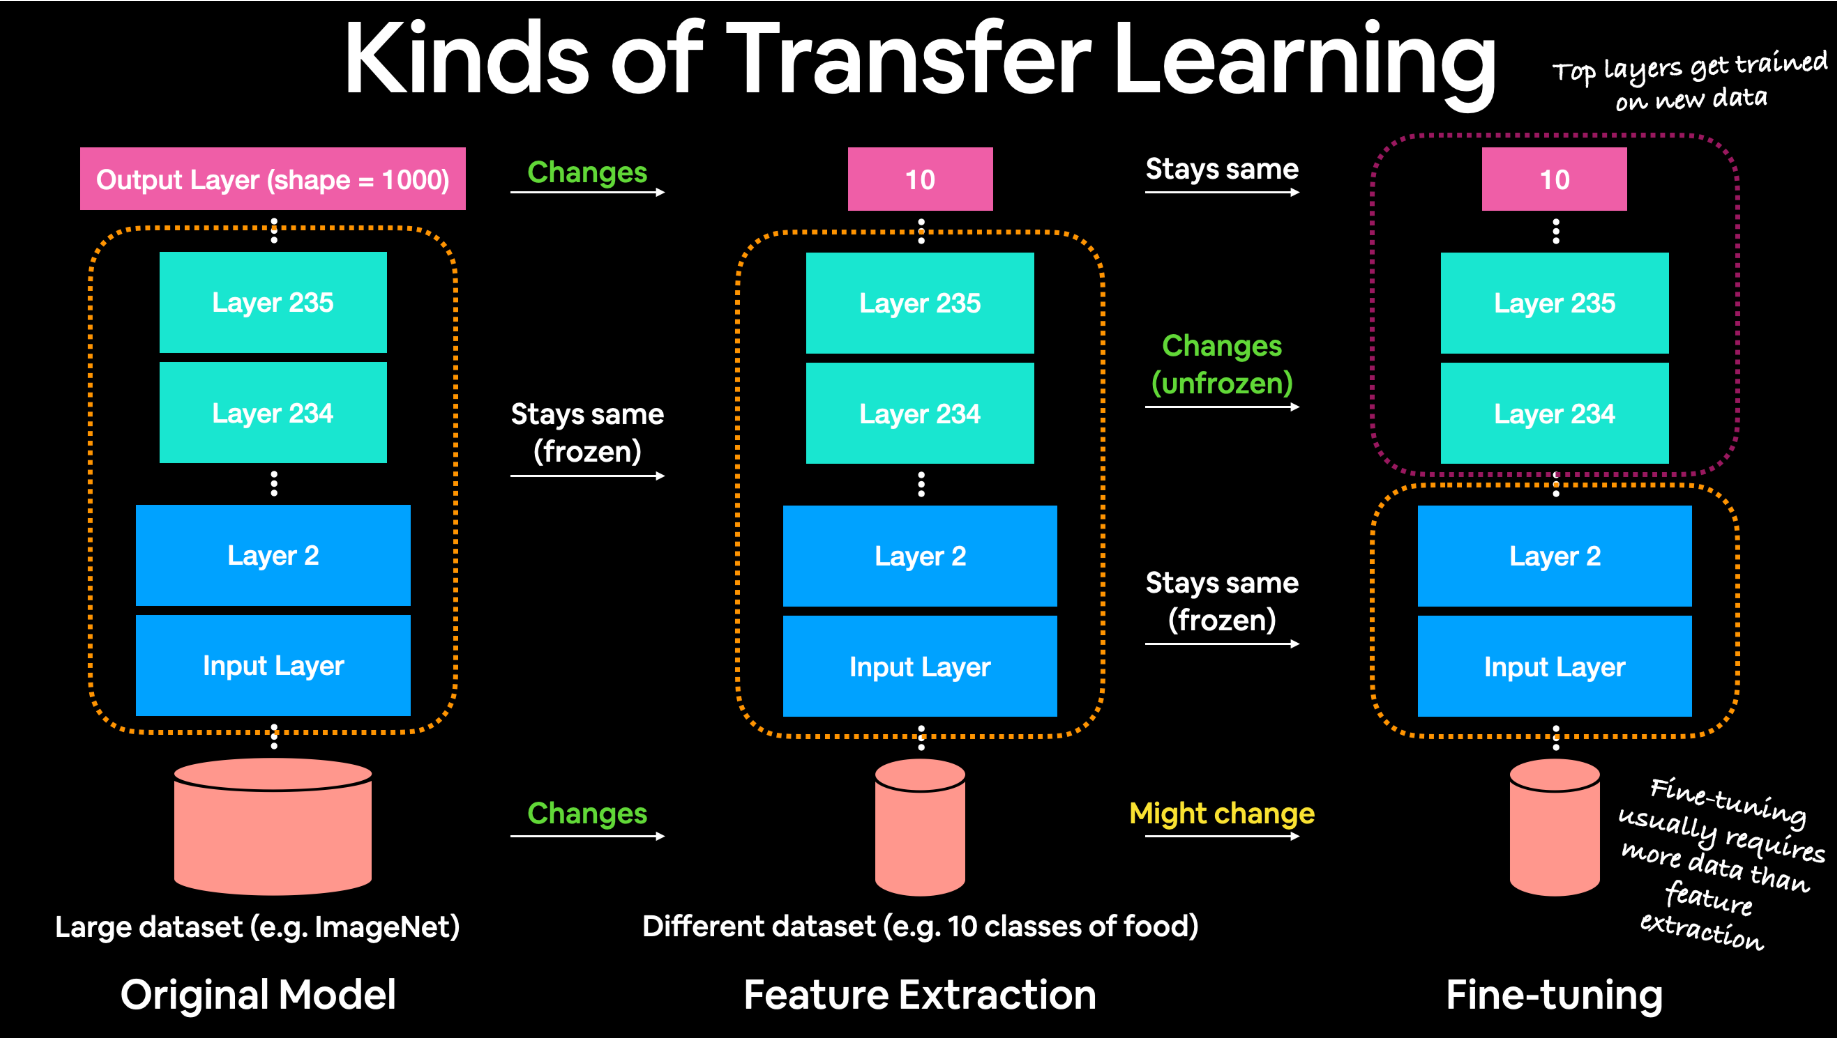

In [1]:
# Are we using a GPU?
!nvidia-smi

Wed Apr 22 15:58:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 4000 Ada Gene...    Off |   00000000:01:00.0 Off |                  Off |
| N/A   52C    P8              7W /   90W |      12MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# # Get data (10% of labels)
# import zipfile

# # Download data
# !wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# # Unzip the downloaded file
# zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip", "r")
# zip_ref.extractall()
# zip_ref.close()

In [3]:

# How many images in each folder?
import os

# Walk through 10 percent data directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/test'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/steak'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_10_percent/test

In [4]:
# Create tensorboard callback (functionized because need to create a new one for each model)
import datetime
import tensorflow as tf 

def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback
     

I0000 00:00:1776866298.775674 1177834 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776866298.804792 1177834 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776866299.508360 1177834 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
# Creating data loaders (preparing the data)
import tensorflow as tf

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


W0000 00:00:1776866300.400779 1177834 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
images, labels = next(iter(train_ds))

one_image  = images[0]
one_label  = labels[0]

print(one_image.shape)   # (224, 224, 3)
print(one_label.numpy()) # one-hot vector
print(images.dtype)          # should be tf.uint8
print(tf.reduce_min(images), tf.reduce_max(images))

(224, 224, 3)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
<dtype: 'float32'>
tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(255.0, shape=(), dtype=float32)


In fact, we're going to use two models from TensorFlow Hub:

* **ResNetV2** - a state of the art computer vision model architecture from 2016.
* **EfficientNet** - a state of the art computer vision architecture from 2019.


In [ ]:
#ResNetV2 model
import tensorflow as tf
from tensorflow.keras import layers

def create_resnetv2_model(num_classes, image_shape=(224, 224, 3)):
    base_model = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights="imagenet",
        input_shape=image_shape
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=image_shape)
    x = tf.keras.applications.resnet_v2.preprocess_input(inputs) #rescale to 0-1(normalization)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)

In [8]:
#EfficientNet model
#EfficientNet already includes a Rescaling layer internally and expects float inputs in [0, 255]
import tensorflow as tf
from tensorflow.keras import layers

def create_efficientnet_model(num_classes, image_shape=(224, 224, 3)):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=image_shape
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

In [9]:
num_classes = len(train_ds.class_names)

resnet_model = create_resnetv2_model(num_classes)
efficientnet_model = create_efficientnet_model(num_classes)

In [ ]:
num_classes = len(train_ds.class_names)

resnet_model = create_resnetv2_model(num_classes)  # new creation

resnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",          # or "val_accuracy"
    patience=5,                  # 5 epochs with no improvement
    restore_best_weights=True,   # roll back to best epoch
    verbose=1
)

resnet_history = resnet_model.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",experiment_name="resnet50V2_2nd"), early_stopping])

Saving TensorBoard log files to: tensorflow_hub/resnet50V2_2nd/20260422-155822
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.3627 - loss: 1.8840 - val_accuracy: 0.6492 - val_loss: 1.1452
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7187 - loss: 0.9346 - val_accuracy: 0.7196 - val_loss: 0.8887
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8067 - loss: 0.6559 - val_accuracy: 0.7528 - val_loss: 0.7678
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8693 - loss: 0.5074 - val_accuracy: 0.7752 - val_loss: 0.6988
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8960 - loss: 0.4001 - val_accuracy: 0.7752 - val_loss: 0.6845
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9267 - loss: 0.3353 - val_accuracy: 0.7876 - val_loss: 0.6524
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9547 - loss: 0.2736 - val_accuracy: 0.7832 - val_loss: 0.6514
Epoch 8/100
24/24 ━━━━━━━━━━━━━━

In [ ]:
from utils import plot_training_history

plot_training_history(resnet_history)


In [ ]:
# Resnet summary 
resnet_model.summary()

In [ ]:
num_classes = len(train_ds.class_names)

efficientnet_model = create_efficientnet_model(num_classes)  # new creation

efficientnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",          # or "val_accuracy"
    patience=5,                  # 5 epochs with no improvement
    restore_best_weights=True,   # roll back to best epoch
    verbose=1
)

efficientnet_history = efficientnet_model.fit(
    train_ds,
    epochs=100,
    validation_data=test_ds,
    callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",experiment_name="efficientnetB0_2nd"), early_stopping]
)

In [ ]:
plot_training_history(efficientnet_history)

In [ ]:
efficientnet_model.summary()

### How to see results in tensorboard

In [ ]:
%load_ext tensorboard
%tensorboard --logdir tensorflow_hub
# !tensorboard --logdir=tensorflow_hub --port=6006